#2.3.1

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)

import matplotlib.pyplot as plt


Загрузка датасет

In [6]:
DATA_PATH = "S05-hw-dataset.csv"

df = pd.read_csv(DATA_PATH)

#пункт 3


In [9]:
df.head() #первые 5 элементов


,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


In [10]:
df.info() #информацию о столбцах

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

In [13]:
df.describe().T #базовые описательные статистики для числовых признаков

,count,mean,std,min,25%,50%,75%,max
client_id,3000.0,1500.500000,866.169729,1.000000,750.750000,1500.500000,2250.250000,3000.000000
age,3000.0,45.059667,14.192883,21.000000,33.000000,45.000000,57.000000,69.000000
income,3000.0,69658.992000,24742.235182,15000.000000,52641.750000,69784.500000,85874.250000,156351.000000
years_employed,3000.0,19.577667,11.381497,0.000000,10.000000,20.000000,29.000000,39.000000
credit_score,3000.0,649.285333,69.955852,402.000000,604.000000,647.000000,697.000000,850.000000
debt_to_income,3000.0,0.284065,0.161112,0.006147,0.157796,0.261726,0.388886,0.878343
num_credit_cards,3000.0,3.494667,2.289917,0.000000,1.000000,3.000000,6.000000,7.000000
num_late_payments,3000.0,6.869333,4.291278,0.000000,3.000000,7.000000,10.000000,14.000000
has_mortgage,3000.0,0.495000,0.500058,0.000000,0.000000,0.000000,1.000000,1.000000
has_car_loan,3000.0,0.501333,0.500082,0.000000,0.000000,1.000000,1.000000,1.000000


In [14]:
df["default"].value_counts(normalize=True) #распределение целевого признака default

,proportion
default,
0,0.589667
1,0.410333


#Пункт 4

In [15]:
#наблюдения


#2.3.2

In [21]:
TARGET_COL = "default" #Выделил матрицу признаков X и вектор таргет
ID_COL = "client_id"

# Таргет
y = df[TARGET_COL]

# Признаки: все, кроме target и client_id
X = df.drop(columns=[TARGET_COL, ID_COL])

print("X shape:", X.shape)
print("y shape:", y.shape)

X.dtypes






X shape: (3000, 15)
y shape: (3000,)


,0
age,int64
income,int64
years_employed,int64
credit_score,int64
debt_to_income,float64
num_credit_cards,int64
num_late_payments,int64
has_mortgage,int64
has_car_loan,int64
savings_balance,int64


In [22]:
# проверка диапазона debt_to_income должен быть в диапазоне [0, 1]
print(
    "debt_to_income min/max:",
    X["debt_to_income"].min(),
    X["debt_to_income"].max(),
)

# проверка диапазона region_risk_score тоже ожидается в [0, 1]
print(
    "region_risk_score min/max:",
    X["region_risk_score"].min(),
    X["region_risk_score"].max(),
)


debt_to_income min/max: 0.0061471149847966 0.878343349584274
region_risk_score min/max: 0.0011480532639611 0.9617329449691724


#2.3.3

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)


In [24]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)

dummy_clf.fit(X_train, y_train)


DummyClassifier(random_state=42, strategy='most_frequent')

In [25]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Предсказания классов
y_pred_dummy = dummy_clf.predict(X_test)

# Вероятности для ROC-AUC
y_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy)

print(f"Dummy accuracy: {accuracy_dummy:.3f}")
print(f"Dummy ROC-AUC:  {roc_auc_dummy:.3f}")


Dummy accuracy: 0.590
Dummy ROC-AUC:  0.500


Dummy всегда предсказывает самый часты класс. Такая модель мождель часто используется как нижний порог качества (точка отсчета)

In [32]:
import os
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, confusion_matrix, classification_report


data = load_breast_cancer()
X = data.data
y = data.target

# Разбиваем данные на тренировочные и тестовые
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Создаем Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=1000))
])

In [33]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000))]),
             param_grid={'logreg__C': [0.01, 0.1, 1.0, 10.0, 100.0]},
             scoring='roc_auc')

In [34]:
# Лучшая модель
best_model = grid_search.best_estimator_
print("Лучший параметр C:", grid_search.best_params_)

# Предсказания на тестовой выборке
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

Лучший параметр C: {'logreg__C': 0.1}


Accuracy: 0.9825
ROC-AUC: 0.9984
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion Matrix:
[[41  2]
 [ 0 71]]


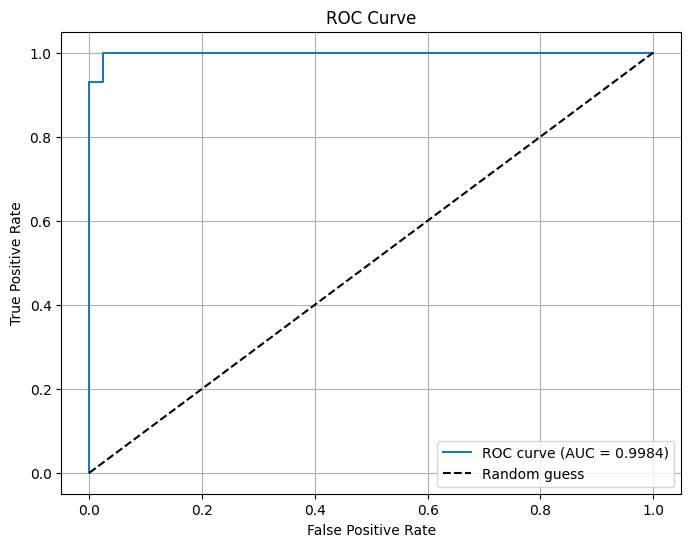

In [36]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Дополнительно: precision, recall, f1, confusion matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)

# Сохраняем график
plt.savefig("./figures/roc_curve.png")
plt.show()

#2.3.5

In [42]:
# Импорт дополнительных библиотек
import pandas as pd
from sklearn.dummy import DummyClassifier

# --- 1. Бейзлайн модель ---
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)
y_dummy_proba = dummy.predict_proba(X_test)[:,1]

# Метрики бейзлайна
dummy_accuracy = accuracy_score(y_test, y_dummy_pred)
dummy_roc_auc = roc_auc_score(y_test, y_dummy_proba)

# --- 2. Логистическая регрессия (лучший C из GridSearchCV) ---
logreg_accuracy = accuracy_score(y_test, y_pred)
logreg_roc_auc = roc_auc_score(y_test, y_pred_proba)

# --- 3. Сводим результаты в таблицу ---
results_df = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [dummy_accuracy, logreg_accuracy],
    "ROC-AUC": [dummy_roc_auc, logreg_roc_auc]
})
results_df.to_csv("./artifacts/model_comparison.csv", index=False)
print(results_df)


                Model  Accuracy   ROC-AUC
0     DummyClassifier  0.622807  0.500000
1  LogisticRegression  0.982456  0.998362


Logistic Regression является разумным выбором для данной задачи классификации.
Бейзлайн полезен для оценки минимального качества, но реальная модель должна его превосходить.
Правильный подбор регуляризации важен для баланса между переобучением и недообучением.